In [ ]:
# === Initialisation : chargement du dataset ===
import os
import pandas as pd

data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data", "COVID-19_Radiography_Dataset")

data = []
for category in os.listdir(data_dir):
    folder_images = os.path.join(data_dir, category, "images")
    if os.path.isdir(folder_images):
        for file in os.listdir(folder_images):
            if file.endswith(".png") or file.endswith(".jpg"):
                data.append({
                    "image_path": os.path.join(folder_images, file),
                    "label": category
                })

df_images = pd.DataFrame(data)
print(f"Dataset charge : {len(df_images)} images")
print(df_images['label'].value_counts())

In [ ]:
# === Initialisation : preprocessing des images ===
import numpy as np
from PIL import Image

TARGET_SIZE = (256, 256)

def preprocess_image(path):
    img = Image.open(path).convert('L')
    img = img.resize(TARGET_SIZE)
    img_array = np.array(img, dtype=np.float32) / 255.0
    return img_array

print("Preprocessing des images...")
X_list = [preprocess_image(p) for p in df_images['image_path']]
print(f"X_list : {len(X_list)} images preprocessees")

In [53]:
#Étape 3/ Modélisation
#STEP 1 Deadline 
#Dans cette première étape, nous préparons le dataset pour le machine learning classique en encodant les labels, en normalisant et
#en redimensionnant les images, en les transformant en vecteurs exploitables par les modèles, puis en séparant le dataset en ensembles
#d’entraînement et de test. Nous entraînons ensuite un modèle baseline (Random Forest) pour établir une référence de performance.

In [16]:

#STEP 1 – Baseline : Encodage des labels et train/test split

#Récupération de toutes les images et labels

#Encodage des labels

#Redimensionnement et normalisation des images

#Flatten des images pour les modèles ML classiques

#Séparation train/test (80 % / 20 %)

#Entraînement d’un modèle baseline (Random Forest)

#Évaluation du modèle (accuracy, matrice de confusion, classification report)



# =============================================
# STEP 1 – BASELINE : Encodage des labels et train/test split (toutes les images)
# =============================================



from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
from collections import Counter

# ------------------------------
# 1️⃣ Récupération de toutes les images et labels
# ------------------------------
# Objectif : utiliser tout le dataset (~21 165 images)
X_all = np.array(X_list, dtype=np.float32)  # images pré-traitées
y_labels_all = df_images['label'].values   # labels originaux

print("Nombre total d'images :", X_all.shape[0])

# ------------------------------
# 2️⃣ Encodage des labels
# ------------------------------
# Les modèles ML classiques ne comprennent que des valeurs numériques
le = LabelEncoder()
y_all = le.fit_transform(y_labels_all)
print("Labels encodés :", np.unique(y_all))
print("Distribution des labels :", Counter(y_labels_all))

# ------------------------------
# 3️⃣ Flatten pour ML classique (sklearn)
# ------------------------------
# Les modèles sklearn comme RandomForest ou SVM attendent des vecteurs 1D
# Chaque image 2D (256x256) est transformée en vecteur de taille 65536 (256*256)
X_flat_all = X_all.reshape(X_all.shape[0], -1)
print("Shape de X_flat pour ML :", X_flat_all.shape)

# ------------------------------
# 4️⃣ Séparation train/test
# ------------------------------
# Objectif : entraîner le modèle sur une partie du dataset et tester sur le reste
# stratify=y_all assure que la répartition des classes reste équilibrée dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Nombre total d'images : 21165
Labels encodés : [0 1 2 3]
Distribution des labels : Counter({'Normal': 10192, 'Lung_Opacity': 6012, 'COVID': 3616, 'Viral Pneumonia': 1345})
Shape de X_flat pour ML : (21165, 65536)
Train size: 16932, Test size: 4233


=== Étape 1️⃣ : Redimensionnement des images à 64x64 ===
Shape de X_small : (21165, 64, 64)
=== Étape 2️⃣ : Flatten des images pour ML classique ===
Shape de X_flat pour ML : (21165, 4096)
=== Étape 3️⃣ : Encodage des labels ===
Labels encodés : [0 1 2 3]
=== Étape 4️⃣ : Séparation train/test ===
Train size: 16932, Test size: 4233
=== Étape 5️⃣ : Entraînement du modèle Random Forest ===
=== Étape 6️⃣ : Évaluation du modèle ===
Accuracy sur le jeu test : 0.8172


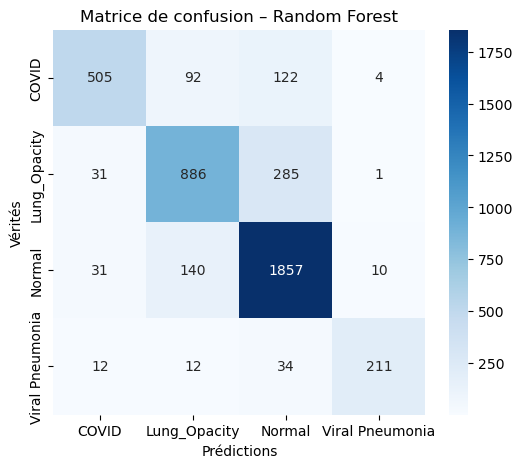


Classification Report :

                 precision    recall  f1-score   support

          COVID       0.87      0.70      0.78       723
   Lung_Opacity       0.78      0.74      0.76      1203
         Normal       0.81      0.91      0.86      2038
Viral Pneumonia       0.93      0.78      0.85       269

       accuracy                           0.82      4233
      macro avg       0.85      0.78      0.81      4233
   weighted avg       0.82      0.82      0.81      4233



In [17]:

# =============================================
# STEP 1 – BASELINE MODEL OPTIMISE : Random Forest
# =============================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

print("=== Étape 1️⃣ : Redimensionnement des images à 64x64 ===")
# ------------------------------
# 1️⃣ Redimensionnement des images à 64x64
# ------------------------------
TARGET_SIZE = (64, 64)
X_small = np.array([cv2.resize(img, TARGET_SIZE) for img in X_list], dtype=np.float32) / 255.0
print("Shape de X_small :", X_small.shape)  # (21165, 64, 64)
print("=== Étape 2️⃣ : Flatten des images pour ML classique ===")
# ------------------------------
# 2️⃣ Flatten pour ML classique
# ------------------------------
X_flat = X_small.reshape(X_small.shape[0], -1)
print("Shape de X_flat pour ML :", X_flat.shape)  # 21165, 4096
print("=== Étape 3️⃣ : Encodage des labels ===")
# ------------------------------
# 3️⃣ Encodage des labels
# ------------------------------
le = LabelEncoder()
y = le.fit_transform(df_images['label'].values)
print("Labels encodés :", np.unique(y))
print("=== Étape 4️⃣ : Séparation train/test ===")
# ------------------------------
# 4️⃣ Train/test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print("=== Étape 5️⃣ : Entraînement du modèle Random Forest ===")
# ------------------------------
# 5️⃣ Random Forest
# ------------------------------
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)  # n_jobs=-1 pour utiliser tous les coeurs
rf_model.fit(X_train, y_train)
print("=== Étape 6️⃣ : Évaluation du modèle ===")
# Prédictions
y_pred = rf_model.predict(X_test)
# Évaluation
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy sur le jeu test : {acc:.4f}")
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de confusion – Random Forest")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()
# Classification report
print("\nClassification Report :\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))



#Le modèle obtient une précision et un rappel globalement bons, avec une accuracy de 82 %.
#La classe “Normal” est bien prédite (rappel 0.92), tandis que la classe “COVID” présente un rappel plus faible (0.69), 
#ce qui signifie que certaines images COVID sont mal classées. Les autres classes (“Lung_Opacity” et “Viral Pneumonia”) ont des performances
#intermédiaires mais correctes. Le F1-score montre un bon équilibre global entre précision et rappel, mais il indique que l’on pourrait encore 
#améliorer la détection des classes les plus critiques comme “COVID”

In [18]:
from sklearn.metrics import f1_score

# ------------------------------
#  Calcul des F1-scores
# ------------------------------
# F1-score macro : moyenne des F1 de chaque classe (équilibre toutes les classes)
f1_macro = f1_score(y_test, y_pred, average='macro')

# F1-score micro : considère tous les échantillons également (pondéré par support)
f1_micro = f1_score(y_test, y_pred, average='micro')

print(f"F1-score macro : {f1_macro:.4f}")
print(f"F1-score micro : {f1_micro:.4f}")


#Le modèle Random Forest montre de bonnes performances globales (F1-score macro ≈ 0.81, micro ≈ 0.82).
#Il prédit bien les classes majoritaires comme “Normal”, mais les classes moins représentées ou plus difficiles à distinguer, 
#comme “COVID”, ont un rappel plus faible. Une optimisation ciblée pourrait améliorer ces classes spécifiques.

F1-score macro : 0.8111
F1-score micro : 0.8172
